# 02 — Tour of the model families

The suite has one emulator *family* per cosmological model, each split into neutrino variants and products
(linear, nonlinear, CDM+baryon, $\sigma_8$/$f\sigma_8$). This notebook walks through them with the plain
CosmoPower-JAX interface (see `01_quickstart_standalone.ipynb` for the basics):

| Family | Folder | ν variants | Nonlinear | Extra inputs |
|---|---|---|---|---|
| ΛCDM | `lcdm/hmcode`, `lcdm/halofit` | 0mass, 1mass, 2mass, 3mass | HMCode2020 / Halofit | `mnu`, (`logT_AGN`) |
| wCDM | `wcdm/hmcode`, `wcdm/halofit` | same | HMCode2020 / Halofit | `w` |
| w0waCDM | `w0wa/hmcode`, `w0wa/halofit` | same | HMCode2020 / Halofit | `w0`, `wa` |
| Curvature (on ΛCDM and w0waCDM) | `extended/curvature` | 0mass, 1mass, 3mass | HMCode2020 | `omk` |
| Running (on ΛCDM and w0waCDM) | `extended/running` | 0mass, 1mass, 3mass | HMCode2020 | `alpha_s` |

File names follow `[halofit-][curvature-|nrun-]<family>-<ν tag>-<product>.npz`. Sections:

1. neutrino variants;
2. dark energy: wCDM and w0waCDM;
3. nonlinear prescriptions: HMCode2020 (with baryonic feedback) versus Halofit;
4. spatial curvature;
5. running of the spectral index;
6. a consistency check across families at their common ΛCDM point.

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX

# The notebooks live in notebooks/, the emulators one level up.
EMU_DIR = next(p for p in ["../emulators", "emulators"] if os.path.isdir(p))

def load(relpath, probe="custom_log"):
    """Load one emulator file.
    probe='custom_log' : P(k) emulators, MG boosts and the DDM distances file (they store log10 of the target,
                         predict() returns the de-logged quantity)
    probe='custom'     : sigma8/fsigma8, DDM growth and DDM global emulators (values stored directly)"""
    return CosmoPowerJAX(probe=probe, filepath=os.path.join(EMU_DIR, relpath), verbose=False)

def predict(emu, **params):
    """Evaluate `emu` from keyword inputs. Scalars are broadcast against array-valued inputs,
    keys the emulator does not use are ignored. Returns an array of shape (n_samples, n_outputs)."""
    arrs = {k: np.atleast_1d(np.asarray(v, dtype=float)) for k, v in params.items()}
    missing = [p for p in emu.parameters if p not in arrs]
    if missing:
        raise KeyError(f"missing inputs {missing}; this emulator expects {list(emu.parameters)}")
    n = max(a.size for a in arrs.values())
    inputs = {p: (np.full(n, arrs[p][0]) if arrs[p].size == 1 else arrs[p]) for p in emu.parameters}
    return np.atleast_2d(np.asarray(emu.predict(inputs)))

plt.rcParams.update({"font.size": 11, "figure.dpi": 100})

# Planck-2018-like fiducial point, in the parameter names used by the CAMB-family emulators
PLANCK = dict(ombh2=0.0224, omch2=0.120, H0=67.4, ns=0.965, lnAs=3.044)
print("emulator directory:", os.path.abspath(EMU_DIR))

emulator directory: /Users/ivan/Desktop/dr1-matter-emulators/emulators


## 1. Neutrino variants

The tag selects how $N_{\rm eff} = 3.044$ is split between massless and massive species: `0mass` (all massless,
no `mnu` input), `1mass` (one massive eigenstate carrying $\Sigma m_\nu$), `2mass` and `3mass` (two or three
degenerate massive eigenstates). `mnu` is always the total mass sum in eV. On small scales the linear
suppression tends to $\Delta P/P \simeq -8 f_\nu$ with $f_\nu = \Omega_\nu/\Omega_m$ and
$\Omega_\nu h^2 = \Sigma m_\nu / 93.14\,{\rm eV}$; the right panel shows how the split into eigenstates
changes the shape of the suppression at fixed total mass.

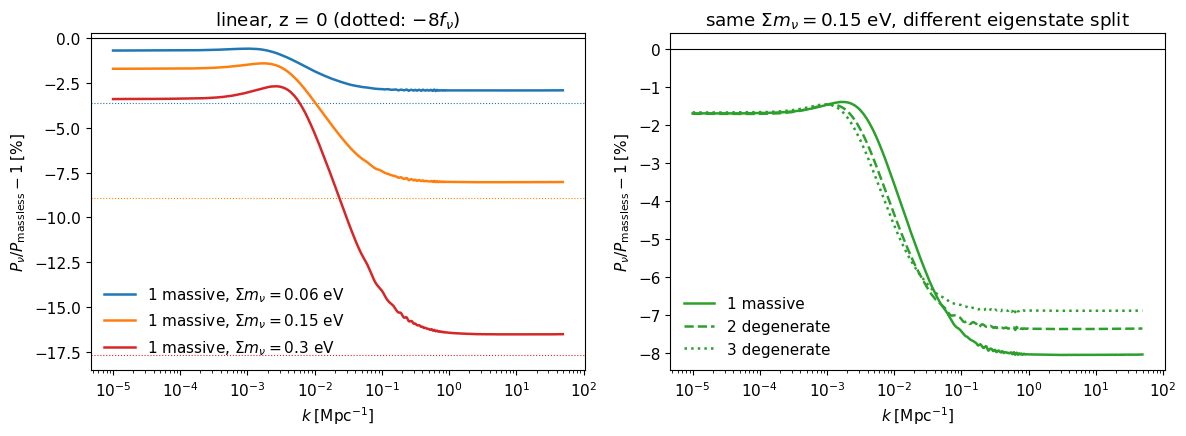

In [2]:
lin0 = load("lcdm/hmcode/lcdm-0mass-linear.npz")    # massless variant: no `mnu` input
lin1 = load("lcdm/hmcode/lcdm-1mass-linear.npz")
lin2 = load("lcdm/hmcode/lcdm-2mass-linear.npz")
lin3 = load("lcdm/hmcode/lcdm-3mass-linear.npz")
k = np.asarray(lin0.modes)

p0 = predict(lin0, **PLANCK, z=0.0)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for mnu, c in zip([0.06, 0.15, 0.30], ["C0", "C1", "C3"]):
    p1 = predict(lin1, **PLANCK, mnu=mnu, z=0.0)[0]
    f_nu = (mnu / 93.14) / (PLANCK["ombh2"] + PLANCK["omch2"] + mnu / 93.14)
    axes[0].semilogx(k, 100 * (p1 / p0 - 1), color=c, lw=1.8, label=rf"1 massive, $\Sigma m_\nu={mnu}$ eV")
    axes[0].axhline(-800 * f_nu, color=c, lw=0.8, ls=":")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_\nu / P_{\rm massless} - 1\;[\%]$", title=r"linear, z = 0 (dotted: $-8f_\nu$)")
axes[0].legend(frameon=False)

mnu = 0.15
for emu, ls, lab in [(lin1, "-", "1 massive"), (lin2, "--", "2 degenerate"), (lin3, ":", "3 degenerate")]:
    p = predict(emu, **PLANCK, mnu=mnu, z=0.0)[0]
    axes[1].semilogx(k, 100 * (p / p0 - 1), color="C2", ls=ls, lw=1.8, label=lab)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_\nu / P_{\rm massless} - 1\;[\%]$", title=rf"same $\Sigma m_\nu = {mnu}$ eV, different eigenstate split")
axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

## 2. Dark energy: wCDM and w0waCDM

`wcdm-*` files take a constant equation of state `w`; `w0wa-*` files take the CPL pair `w0`, `wa` with
$w(a) = w_0 + w_a(1-a)$. At fixed physical densities and $H_0$ the dark-energy sector changes the expansion
history and therefore the growth, so the effect on $P(k)$ is mostly a scale-independent amplitude shift that
grows towards $z = 0$. ΛCDM is recovered at $w = -1$ (or $w_0 = -1$, $w_a = 0$).

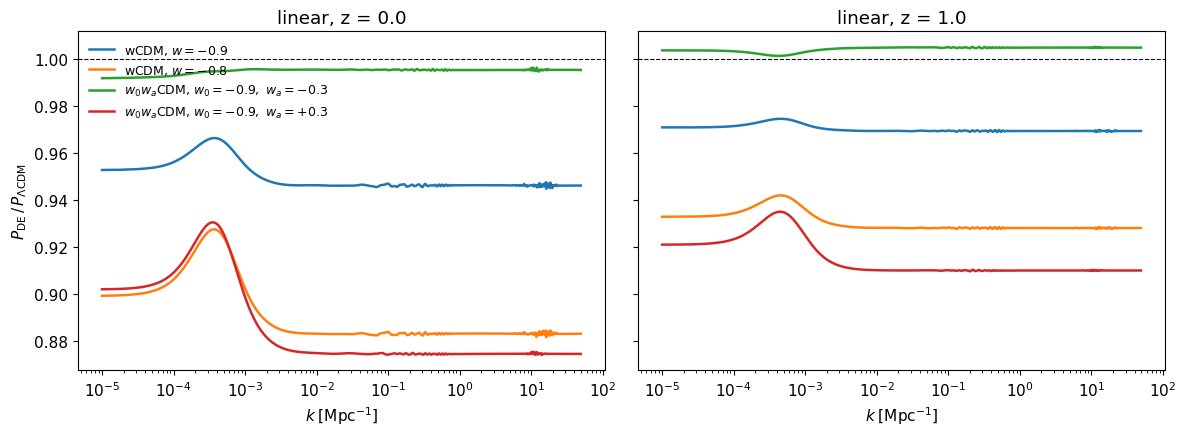

In [3]:
wcdm = load("wcdm/hmcode/wcdm-1mass-linear.npz")
w0wa = load("w0wa/hmcode/w0wa-1mass-linear.npz")
models = [
    (wcdm, dict(w=-0.9),          r"wCDM, $w=-0.9$",                "C0"),
    (wcdm, dict(w=-0.8),          r"wCDM, $w=-0.8$",                "C1"),
    (w0wa, dict(w0=-0.9, wa=-0.3), r"$w_0w_a$CDM, $w_0=-0.9,\ w_a=-0.3$", "C2"),
    (w0wa, dict(w0=-0.9, wa=+0.3), r"$w_0w_a$CDM, $w_0=-0.9,\ w_a=+0.3$", "C3"),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, z in zip(axes, [0.0, 1.0]):
    p_lcdm = predict(lin1, **PLANCK, mnu=0.06, z=z)[0]
    for emu, de, lab, c in models:
        p = predict(emu, **PLANCK, mnu=0.06, **de, z=z)[0]
        ax.semilogx(k, p / p_lcdm, color=c, lw=1.8, label=lab)
    ax.axhline(1, color="k", lw=0.8, ls="--")
    ax.set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", title=f"linear, z = {z}")
axes[0].set_ylabel(r"$P_{\rm DE}\,/\,P_{\Lambda{\rm CDM}}$"); axes[0].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 3. Nonlinear prescriptions: HMCode2020 versus Halofit

The same cosmologies come with two nonlinear prescriptions. `hmcode/` files use HMCode2020, an augmented halo
model with a one-parameter baryonic-feedback model: `logT_AGN` is an input of the nonlinear emulators, and
larger values suppress small-scale power more. `halofit/` files use the Takahashi recalibration of Halofit,
which is gravity-only and has no feedback parameter. The ratio between the two mixes the different
calibrations of the nonlinear correction with the presence or absence of feedback.

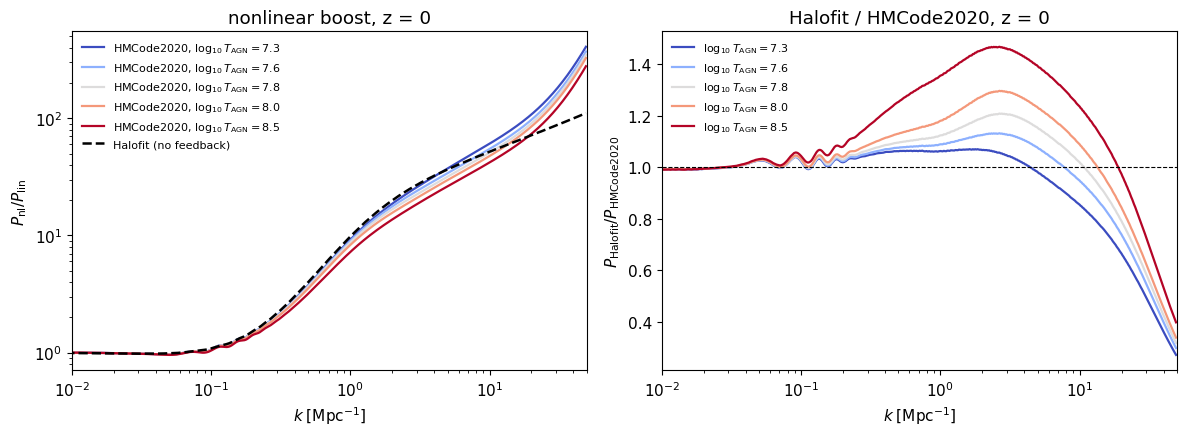

In [4]:
nl_hm = load("lcdm/hmcode/lcdm-1mass-nonlinear.npz")
nl_hf = load("lcdm/halofit/halofit-lcdm-1mass-nonlinear.npz")      # inputs: no logT_AGN
p_lin = predict(lin1, **PLANCK, mnu=0.06, z=0.0)[0]
p_hf  = predict(nl_hf, **PLANCK, mnu=0.06, z=0.0)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
tagn = [7.3, 7.6, 7.8, 8.0, 8.5]
colors = plt.cm.coolwarm(np.linspace(0, 1, len(tagn)))
for t, c in zip(tagn, colors):
    p_hm = predict(nl_hm, **PLANCK, mnu=0.06, logT_AGN=t, z=0.0)[0]
    axes[0].semilogx(k, p_hm / p_lin, color=c, lw=1.6, label=rf"HMCode2020, $\log_{{10}}T_{{\rm AGN}}={t}$")
    axes[1].semilogx(k, p_hf / p_hm, color=c, lw=1.6, label=rf"$\log_{{10}}T_{{\rm AGN}}={t}$")
axes[0].semilogx(k, p_hf / p_lin, color="k", lw=1.8, ls="--", label="Halofit (no feedback)")
axes[0].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\rm nl}/P_{\rm lin}$", yscale="log", title="nonlinear boost, z = 0", xlim=(1e-2, 50))
axes[0].legend(frameon=False, fontsize=8)
axes[1].axhline(1, color="k", lw=0.8, ls="--")
axes[1].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\rm Halofit}/P_{\rm HMCode2020}$", title="Halofit / HMCode2020, z = 0", xlim=(1e-2, 50))
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 4. Spatial curvature

`curvature-lcdm-*` and `curvature-w0wa-*` add `omk` $= \Omega_k$ to the ΛCDM or w0waCDM inputs. With
$\omega_b$, $\omega_c$ and $H_0$ held fixed, a non-zero $\Omega_k$ changes the dark-energy density
$\Omega_\Lambda = 1 - \Omega_m - \Omega_k$ and hence the growth, which is why $\sigma_8$ moves even though the
primordial amplitude does not. Note the slightly reduced $k$ grid of this family (471 modes starting at
$5.3\times10^{-4}$ Mpc⁻¹): non-zero curvature changes the lowest wavenumber that can be computed.

curvature k-grid: 471 modes from 5.31e-04 Mpc^-1   (ΛCDM grid: 520 modes from 1e-05)


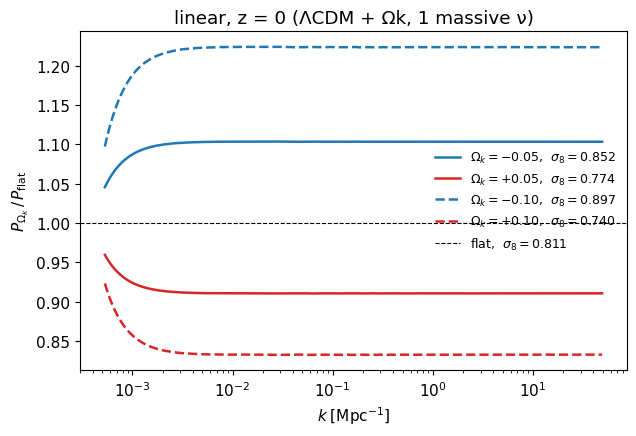

curvature-w0wa inputs: ['ombh2', 'omch2', 'H0', 'ns', 'lnAs', 'z', 'omk', 'w0', 'wa', 'mnu']


In [5]:
curv    = load("extended/curvature/curvature-lcdm-1mass-linear.npz")
curv_s8 = load("extended/curvature/curvature-lcdm-1mass-s8-fs8.npz", probe="custom")
k_curv  = np.asarray(curv.modes)
print(f"curvature k-grid: {len(k_curv)} modes from {k_curv[0]:.2e} Mpc^-1   (ΛCDM grid: {len(k)} modes from {k[0]:.0e})")

p_flat = predict(curv, **PLANCK, mnu=0.06, omk=0.0, z=0.0)[0]
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for omk, c in zip([-0.05, 0.05, -0.10, 0.10], ["C0", "C3", "C0", "C3"]):
    p = predict(curv, **PLANCK, mnu=0.06, omk=omk, z=0.0)[0]
    s8 = predict(curv_s8, **PLANCK, mnu=0.06, omk=omk, logT_AGN=7.6, z=0.0)[0, 0]
    ax.semilogx(k_curv, p / p_flat, color=c, lw=1.8, ls="-" if abs(omk) < 0.08 else "--", label=rf"$\Omega_k={omk:+.2f}$,  $\sigma_8={s8:.3f}$")
s8_flat = predict(curv_s8, **PLANCK, mnu=0.06, omk=0.0, logT_AGN=7.6, z=0.0)[0, 0]
ax.axhline(1, color="k", lw=0.8, ls="--", label=rf"flat,  $\sigma_8={s8_flat:.3f}$")
ax.set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\Omega_k}\,/\,P_{\rm flat}$", title="linear, z = 0 (ΛCDM + Ωk, 1 massive ν)")
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

# the w0waCDM + curvature variant takes w0, wa and omk together
curv_w = load("extended/curvature/curvature-w0wa-1mass-linear.npz")
print("curvature-w0wa inputs:", list(curv_w.parameters))

## 5. Running of the spectral index

`nrun-lcdm-*` and `nrun-w0wa-*` add `alpha_s` $= {\rm d}n_s/{\rm d}\ln k$. The primordial spectrum becomes
$P_{\rm prim}(k) \propto (k/k_\ast)^{\,n_s - 1 + \frac12\alpha_s\ln(k/k_\ast)}$ with pivot $k_\ast = 0.05$ Mpc⁻¹,
so at fixed $A_s$ and transfer function the ratio to the no-running case is
$\exp\!\left[\tfrac12\alpha_s\ln^2(k/k_\ast)\right]$: above unity everywhere for $\alpha_s > 0$ and touching one
only at the pivot. The dotted lines show this analytic expectation on top of the emulator ratio.

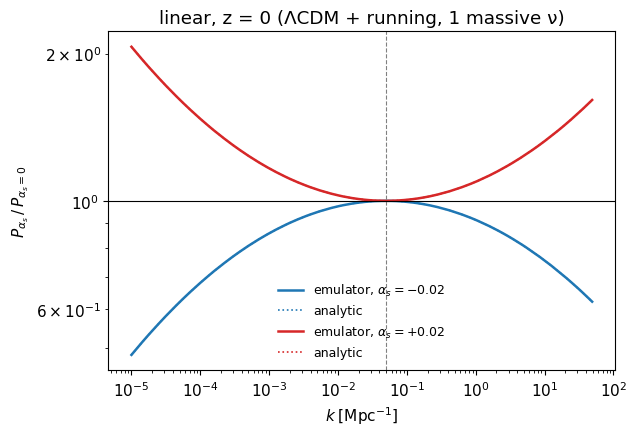

In [6]:
nrun = load("extended/running/nrun-lcdm-1mass-linear.npz")
p_norun = predict(nrun, **PLANCK, mnu=0.06, alpha_s=0.0, z=0.0)[0]
k_pivot = 0.05

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for a_s, c in zip([-0.02, 0.02], ["C0", "C3"]):
    p = predict(nrun, **PLANCK, mnu=0.06, alpha_s=a_s, z=0.0)[0]
    ax.semilogx(k, p / p_norun, color=c, lw=1.8, label=rf"emulator, $\alpha_s={a_s:+.2f}$")
    ax.semilogx(k, np.exp(0.5 * a_s * np.log(k / k_pivot) ** 2), color=c, lw=1.2, ls=":", label="analytic")
ax.axvline(k_pivot, color="grey", lw=0.8, ls="--"); ax.axhline(1, color="k", lw=0.8)
ax.set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\alpha_s}\,/\,P_{\alpha_s=0}$", yscale="log", title="linear, z = 0 (ΛCDM + running, 1 massive ν)")
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

## 6. Consistency across families

Every family contains ΛCDM as a limit: $w = -1$, $(w_0, w_a) = (-1, 0)$, $\Omega_k = 0$, $\alpha_s = 0$. The
families were trained independently (different Latin hypercubes, and in the Halofit case a different training
set), so comparing them at the shared point is a direct test of the emulator error. The spread below is at the
few-per-mille level over the *Euclid* range, consistent with the validation tables in `plots/validation/`.

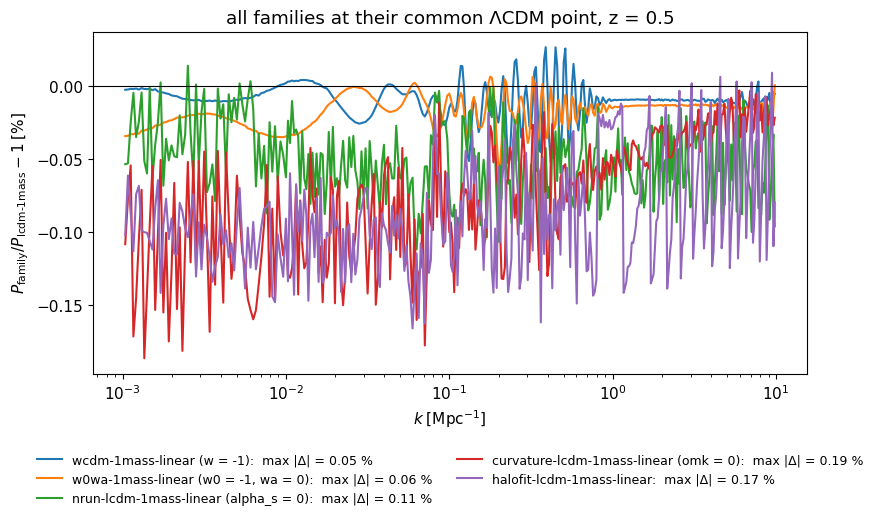

In [7]:
z = 0.5
ref = predict(lin1, **PLANCK, mnu=0.06, z=z)[0]
cases = [
    ("wcdm-1mass-linear (w = -1)",            predict(wcdm, **PLANCK, mnu=0.06, w=-1.0, z=z)[0], k),
    ("w0wa-1mass-linear (w0 = -1, wa = 0)",   predict(w0wa, **PLANCK, mnu=0.06, w0=-1.0, wa=0.0, z=z)[0], k),
    ("nrun-lcdm-1mass-linear (alpha_s = 0)",  predict(nrun, **PLANCK, mnu=0.06, alpha_s=0.0, z=z)[0], k),
    ("curvature-lcdm-1mass-linear (omk = 0)", predict(curv, **PLANCK, mnu=0.06, omk=0.0, z=z)[0], k_curv),
    ("halofit-lcdm-1mass-linear",             predict(load("lcdm/halofit/halofit-lcdm-1mass-linear.npz"), **PLANCK, mnu=0.06, z=z)[0], k),
]
sel = (k > 1e-3) & (k < 10)
fig, ax = plt.subplots(figsize=(9, 5.5))
for lab, p, kk in cases:
    p_on_k = np.exp(np.interp(np.log(k[sel]), np.log(kk), np.log(p)))     # curvature file has its own grid
    d = 100 * (p_on_k / ref[sel] - 1)
    ax.semilogx(k[sel], d, lw=1.5, label=f"{lab}:  max |Δ| = {np.abs(d).max():.2f} %")
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\rm family}/P_{\rm lcdm\text{-}1mass} - 1\;[\%]$", title=f"all families at their common ΛCDM point, z = {z}")
ax.legend(frameon=False, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2); plt.tight_layout(); plt.show()

## Summary

* Pick the folder by model and nonlinear prescription, the file by neutrino variant and product.
* ΛCDM, wCDM and w0waCDM exist with both HMCode2020 and Halofit; curvature and running with HMCode2020 only.
* The Halofit files have no `logT_AGN` input; all HMCode2020 nonlinear files (and their `s8-fs8` companions) do.
* The curvature family has its own, shorter $k$ grid; read it from `emu.modes` rather than assuming the 520-mode grid.

The beyond-ΛCDM emulators (decaying dark matter, parameterised gravity) are covered in `03_beyond_lcdm_ddm_and_mg.ipynb`.